## Tutorial: Grover’s Algorithm

**Instructor:** Hoa Nguyen, CSIRO's Data61

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">  

In this lab, we will focus on implementing **Grover’s Search Algorithm** using Qiskit 2.x

</div>

### **A friendly reminder**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

Code snippets will be provided for you, except in certain cells where your task will be to complete the code to ensure our quantum program runs smoothly. These cells will be clearly marked with a comment like: <span style="font-family: monospace; font-weight: bold; color: #111; background-color: #fff8dc; padding: 2px 6px; border-radius: 4px;"> ### WRITE YOUR CODE BELOW THIS CELL ### </span>.

Another friendly reminder: we’ll be running our quantum programs exclusively on simulators. No worries—these work perfectly well for our purposes.
</div>

## **Pre-checking and Imports**


<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

You should check your Qiskit version before starting the lab. It is recommended to use Qiskit version 2.0 or higher for the best experience.
</div>

In [ ]:
# If you run this notebook on Google Colab, please uncomment the following line and run it first to install the required packages
# !pip install -r https://raw.githubusercontent.com/hoaiocom/rmit-qss-2026/main/requirements.txt

# If you run on local machine, please follow the instructions in the README.md file to setup the virtual environment and install the required packages

In [1]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram

## **Introduction**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
  
Grover's algorithm is a quantum algorithm designed to address the problem of searching for a marked item in an unsorted database, also referred to as an unstructured database. It was introduced by Lov Grover in 1996 and has been proven to provide a quantum advantage over classical computation.

To illustrate the notion of an unstructured database, consider a simple example with a list: `[2, 5, 3, 6, 8, 11, 9, 1]`. In the classical approach, the number of queries required depends on the position of the marked element. On average, one would need to check $\frac N 2$ elements, and in the worst case, $N$ elements, where $N$ denotes the size of the database. The corresponding time complexity is $O(N)$.

In contrast, the quantum approach using Grover’s algorithm achieves a time complexity of $O(\sqrt N)$ for the same problem. This improvement arises from the iterative process of applying the oracle, which inverts the amplitude of the target state, followed by amplitude amplification, thereby increasing the probability of measuring the correct result.
</div>

### **Main Procedure of Grover’s Algorithm**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
  
The central idea of Grover’s algorithm can be summarized as follows:

- Prepare a quantum superposition over all possible states $|\psi \rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |i\rangle_{basic}$, where $N=2^n$ represents the total number of basis states.


- Mark the target state, i.e., the state to be searched, by applying the oracle.

- Amplify the amplitude of the marked state.

- Repeat the oracle and amplitude-amplification steps a number of times (for 2 qubits and one marked state, one iteration is optimal).

- Extract the classical result from the quantum circuit.

*In this tutorial we use $n=2$ qubits, so the search space has $N=4$ basis states $|00\rangle, |01\rangle, |10\rangle, |11\rangle$, and we mark **one** of them. The number of Grover iterations (oracle + amplification) is then chosen accordingly (for 2 qubits and one marked state, one iteration is optimal).*
</div>

## **Algorithm Implementation**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

The figure below illustrates the design of Grover’s algorithm —in this tutorial we use a **two-qubit** circuit (4 basis states) and one marked state.

<img src="grover_circuit.png" alt="VS Code install prompt example" style="display: block; margin-left: auto; margin-right: auto; width: 74%; border: 1px solid #ccc;border-radius: 8px;">
</div>

In [3]:
num_qubits = 2  # Tutorial: 2 qubits → 4 basis states |00⟩, |01⟩, |10⟩, |11⟩
qreg = QuantumRegister(num_qubits, name = "q")
creg = ClassicalRegister(num_qubits, name = "result")

# Marking the State (one marked state for this tutorial)
marked_states = ["10"]

# Since the order of bit strings in Qiskit is reversed, we invert the bit strings prior to marking them in the algorithm for visualization purposes.
reversed_states = [s[::-1] for s in marked_states]

### **Quantum Superposition Initialization**

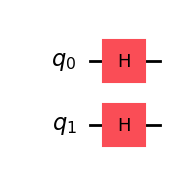

In [4]:
grover_initial = QuantumCircuit(qreg)
grover_initial.h(qreg)

grover_initial.draw('mpl')

### **Oracle Design**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

After preparing the quantum circuit in a superposition of all basis states, the next step is to design an operator, known as the Oracle, to mark the state that encodes the solution to the search problem.

The central idea of this step is to invert the amplitude of the marked states. Formally, this can be expressed as follows:
<div style="text-align: center;"> 

$O_w |\psi\rangle =
\begin{cases}
|\psi\rangle & \text{(} \psi \text{ is not the marked state)} \\
-|\psi\rangle & \text{(} \psi \text{ is the marked state)}
\end{cases}, \space \space \space$      *Let $O_w$ be the oracle, which will be constructed in the following section.*
</div>

For ease of understanding, consider the following example: let $n=2$, which implies that we have a total of 4 states. After preparing the quantum superposition state and marking the state $|10\rangle$, the process can be illustrated as follows: 

<div style="text-align: center;"> 

$O_{w}|\psi\rangle = O_{w} \frac{1}{2}\big( |00\rangle + |01\rangle + |10\rangle + |11\rangle \big)= \frac{1}{2}\big(|00\rangle + |01\rangle - |10\rangle + |11\rangle \big)$
</div>
<div style="text-align: center;"> 

*Or*
</div>

<div style="text-align: center;"> 

$|\psi\rangle = \frac{1}{2}
\begin{pmatrix}
1 \\
1 \\
1 \\
1
\end{pmatrix} \space \rightarrow \space O_w|\psi\rangle = \frac{1}{2}
\begin{pmatrix}
1 \\
1 \\
-1 \\
1
\end{pmatrix}$
</div>

</div>

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 1: Design of the Oracle**
  
Your task is to **design an oracle** that implements **the amplitude inversion of one or more marked states**. The oracle can be constructed by the following procedure:

1. **Iterate** over all marked elements in the list.

2. For each marked bit string, apply **Pauli-X gates** to those qubits whose corresponding bit equals $0$.

3. Apply **a Hadamard gate** to the last qubit (the designated target qubit).

4. Apply **a multi-controlled $Z$ gate** (or equivalently a multi-controlled phase flip) with the last qubit as the target and the remaining qubits as controls.

5. Apply **a Hadamard gate** to the last qubit.

6. For each marked bit string, **undo** the initial Pauli-X gates by applying Pauli-X again to the qubits that were flipped in step $2$ (i.e., uncompute the bit flips).
</div>

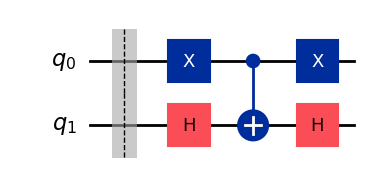

In [5]:
grover_oracle = QuantumCircuit(qreg)
grover_oracle.barrier()

### WRITE YOUR CODE BELOW THIS CELL ###
for x in reversed_states:
    # Apply Pauli-X gates to the positions corresponding to bit 0 in the bit string (for loop)
    for i, bit in enumerate(x):
        if bit == "0":
            grover_oracle.x(i)   
    # Apply a Hadamard gate to the last qubit
    grover_oracle.h(num_qubits - 1)
     
    # Apply a multi-controlled-Z gate with the last qubit as the target and all preceding qubits as controls
    grover_oracle.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    
    # Apply a Hadamard gate to the last qubit
    grover_oracle.h(num_qubits - 1)
    
    # Apply Pauli-X gates again to the positions corresponding to bit 0 in the bit string (for loop)
    for i, bit in enumerate(x):
        if bit == "0":
            grover_oracle.x(i)
    
    
### YOUR CODE FINISHES HERE ###
grover_oracle.draw('mpl')

## **Grover Diffusion Operator Design**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">  

After applying the Oracle, our quantum circuit undergoes a transformation in which the marked states acquire negative amplitudes compared to the others. However, the probability distribution across all states remains uniform, meaning that the marked states are still indistinguishable from the unmarked ones upon measurement.

To resolve this, it is necessary to design an operator that amplifies the amplitudes of the marked states. Mathematically, this operator—known as the diffusion or amplitude amplification operator—is defined as: 

<div style="text-align: center;"> 

$U_{D} = 2|s\rangle\langle s| - \mathbb{I}$
</div>

Here, the state $\ket s$ represents our quantum superposition state, while $U_D$ denotes the amplitude amplification operator, which we are currently designing. From a geometric perspective, this operator reflects the entire state vector about the axis $\ket s$.
</div>

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 2: Construction of the Grover Diffusion Operator**

Design the Grover amplification operator, which modifies the probability distribution over all basis states and increases the measurement probability of the marked states. The operator is implemented by the following sequence of operations:

1. Apply **a Hadamard gate** to every qubit.

2. Apply **Pauli-X gates** to every qubit.

3. Apply **a Hadamard gate** to the last qubit.

4. Apply **a multi-controlled $Z$ gate** with the last qubit as the target and the remaining qubits as controls.

5. Apply **a Hadamard gate** to the last qubit once more.

6. Apply **Pauli-X gates** to every qubit.

7. Apply **a Hadamard gate** to every qubit.
</div>

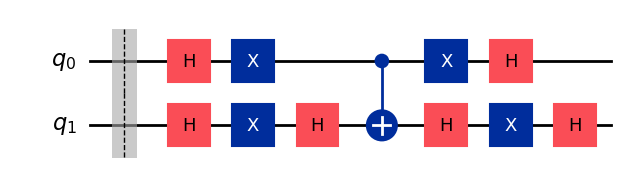

In [6]:
grover_diffuser = QuantumCircuit(qreg)
grover_diffuser.barrier()

### WRITE YOUR CODE BELOW THIS CELL ###
# Apply Hadamard gates to all qubits
for i in range(num_qubits):
    grover_diffuser.h(i)

# Apply Pauli-X gates to all qubits
for i in range(num_qubits):
    grover_diffuser.x(i)

# Apply a Hadamard gate to the last qubit
grover_diffuser.h(num_qubits - 1)

# Apply a multi-controlled-Z gate with the last qubit as the target and the remaining qubits as controls
grover_diffuser.mcx(list(range(num_qubits - 1)), num_qubits - 1)
# Apply a Hadamard gate to the last qubit
grover_diffuser.h(num_qubits - 1)

# Apply Pauli-X gates to all qubits
for i in range(num_qubits):
    grover_diffuser.x(i)

# Apply Hadamard gates to all qubits
for i in range(num_qubits):
    grover_diffuser.h(i)

### YOUR CODE FINISHES HERE ###

grover_diffuser.draw('mpl')

### **Optimal number of iterations**
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

In Grover’s algorithm, it is necessary to repeatedly apply the two operators we have just designed in order for the algorithm to correctly converge to the solution. The number of iterations for applying these two operators is referenced from <a href="https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/grover-algorithm/number-of-iterations?utm_source=chatgpt.com" target="_blank" style="color: #1d73e4ff; text-decoration: none; font-weight: bold;">IBM: Choosing the number of iterations</a>, and is computed according to the following formula:

<div style="text-align: center;"> 

$t_{\text{opt}} = \left\lfloor \frac{\pi}{4 \, \arcsin\!\left(\sqrt{\tfrac{M}{N}}\right)} \right\rfloor$
</div>

Here, $N$ denotes the total number of states corresponding to all possible qubit strings, while $M$ represents the number of marked states.
</div>

In [7]:
import math

# Total number of states corresponding to the number of qubit strings
N = (2 ** num_qubits)
# Number of marked states
M = len(marked_states)
# Compute θ – used to determine the required number of iterations for the algorithm
theta = math.asin(math.sqrt(M / N))
# Compute the optimal number of iterations
t_opt = math.floor(math.pi / (4 * theta))

print("Optimal Number of Iterations:", t_opt)

Optimal Number of Iterations: 1


## **Design of the Complete Algorithm**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 3: Designing the Algorithm**
  
The task is to assemble all components to construct the complete algorithm, which proceeds step by step as follows:

1. Integrate **grover_initial**.

2. Integrate **both grover_oracle** and **grover_diffuser**.

3. **Repeat** the above integration for **$t_{opt}$ iterations**.

4. Apply **measurement gates** to all quantum registers and record the outcomes in the classical register.
</div>

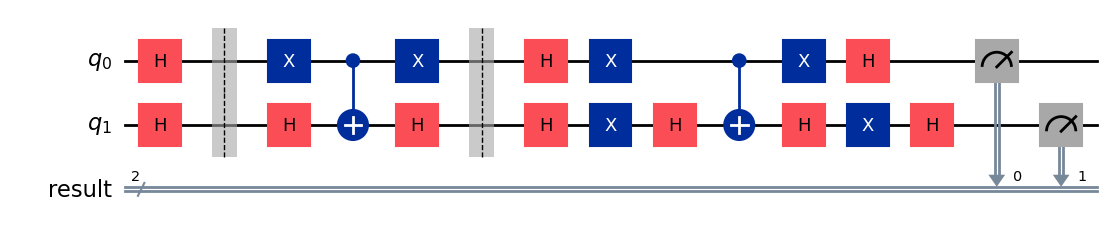

In [8]:
grover_algorithm = QuantumCircuit(qreg, creg)

### WRITE YOUR CODE BELOW THIS CELL ###
# Apply the initial superposition (once)
grover_algorithm.compose(grover_initial, inplace=True)
# Repeat oracle and diffuser t_opt times
for i in range(t_opt):
    grover_algorithm.compose(grover_oracle, inplace=True)
    grover_algorithm.compose(grover_diffuser, inplace=True)

# Apply measurement gates to all qubits and store the results in the corresponding classical registers
for i in range(num_qubits):
    grover_algorithm.measure(qreg[i], creg[i])
### YOUR CODE FINISHES HERE ###

grover_algorithm.draw('mpl')

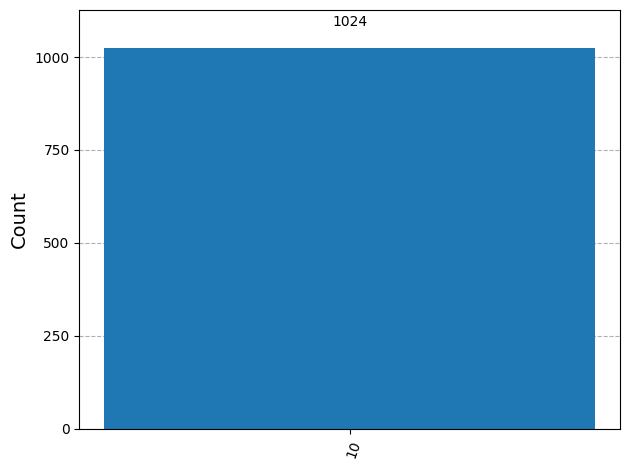

In [9]:
shots = 1024
backend_simulator = AerSimulator()

transpiled_grover_circuit = transpile(grover_algorithm, backend_simulator)
job = backend_simulator.run(transpiled_grover_circuit, shots = shots)
results = job.result()
counts = results.get_counts()

plot_histogram(counts)

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
  
✨ Ta-da! As the results indicate, it is evident that after executing the algorithm, all the initial quantum superposition states have converged to the marked states, demonstrating that our algorithm performs effectively.

🚀 **A little secret**: you can go back to the very first steps of the algorithm, where the number of qubits and the marked states are defined, and modify them. For example, try increasing the number of qubits or marking more than one state instead of just one. You might be surprised by what you discover!
</div>

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

🎉 Congratulations! We have successfully completed the Grover's algorithm implementation

</div>